# Field EDA

In [1]:
import pandas as pd

df = pd.read_csv('../data/assignment-02/field_summary.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   field_id          80 non-null     int64  
 1   crop              80 non-null     str    
 2   field_size_acres  80 non-null     float64
 3   soil_name         80 non-null     str    
 4   soil_component    80 non-null     str    
 5   drainage_class    80 non-null     str    
 6   organic_matter    80 non-null     float64
 7   ph                80 non-null     float64
 8   clay_pct          80 non-null     float64
 9   sand_pct          80 non-null     float64
 10  silt_pct          80 non-null     float64
 11  year              80 non-null     int64  
 12  temp_avg          80 non-null     float64
 13  temp_max_avg      80 non-null     float64
 14  temp_min_avg      80 non-null     float64
 15  precip_total      80 non-null     float64
 16  solar_radiation   80 non-null     float64
 17  humidity  

In [2]:
df.describe()

,field_id,field_size_acres,organic_matter,ph,clay_pct,sand_pct,silt_pct,year,temp_avg,temp_max_avg,temp_min_avg,precip_total,solar_radiation,humidity
count,8.000000e+01,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,3.916230e+14,15.303937,3.446500,6.485000,28.625000,36.030000,35.345000,2021.500000,11.077240,15.817740,6.519560,827.243375,13.975850,75.447954
std,1.437245e+06,9.609810,1.228181,0.317067,13.641778,26.529336,14.196362,1.125088,0.414889,0.801436,1.053496,80.044402,0.214342,1.262271
min,3.916230e+14,2.973755,1.250000,5.900000,5.000000,5.000000,2.000000,2020.000000,9.894356,13.966603,4.405014,717.220000,13.624603,73.108575
25%,3.916230e+14,5.804947,2.375000,6.275000,18.500000,19.000000,34.225000,2020.750000,10.717973,15.436587,5.748852,762.890000,13.864571,74.238685
50%,3.916230e+14,15.445941,3.670000,6.500000,34.750000,25.000000,39.000000,2021.500000,11.175301,16.013986,6.254849,808.990000,13.948603,75.677082
75%,3.916230e+14,20.397605,4.562500,6.700000,36.000000,45.100000,45.250000,2022.250000,11.471712,16.382077,7.230733,851.070000,14.135281,76.381152
max,3.916230e+14,37.803482,4.750000,7.000000,49.000000,93.000000,52.700000,2023.000000,11.665425,17.507096,8.706219,1030.430000,14.310658,77.600109


In [3]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.5 MB/s eta 0:00:00a 0:00:01m


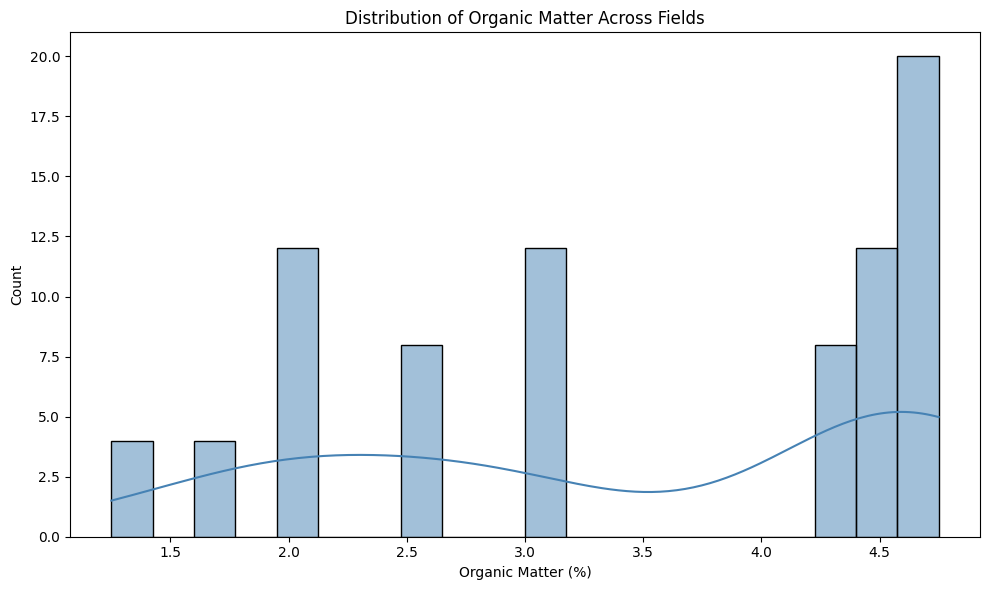

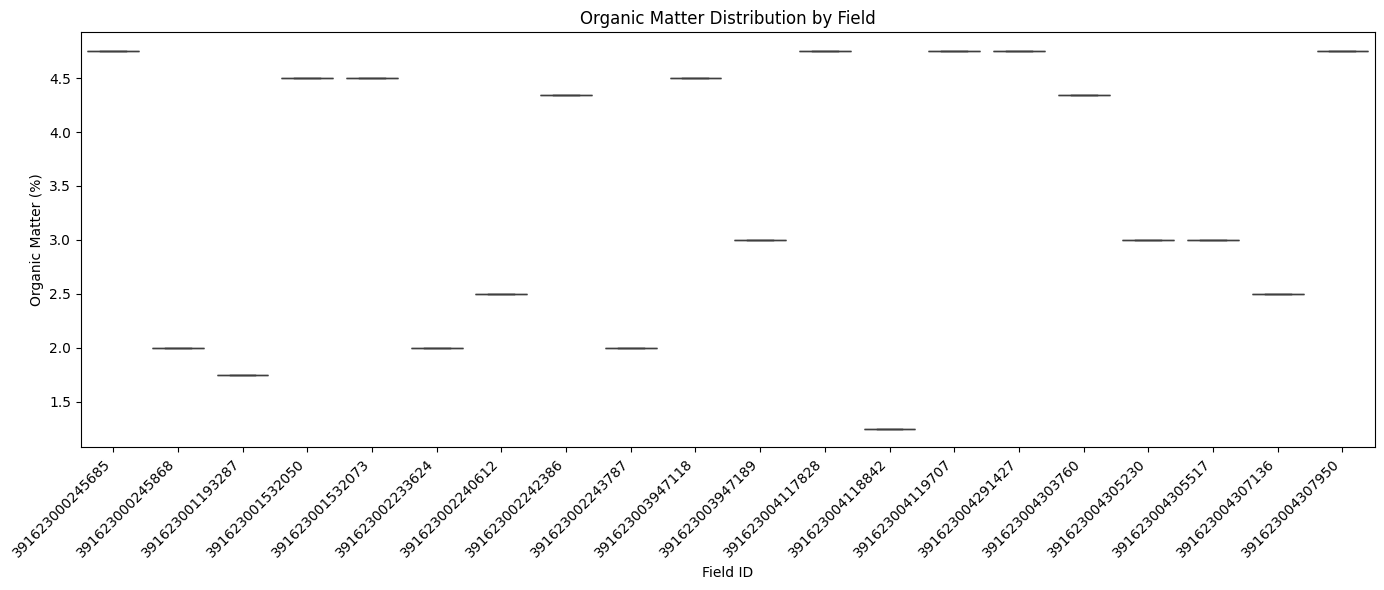

/tmp/ipykernel_9823/619348329.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='field_id', y='organic_matter', data=df, inner='box', palette='muted')


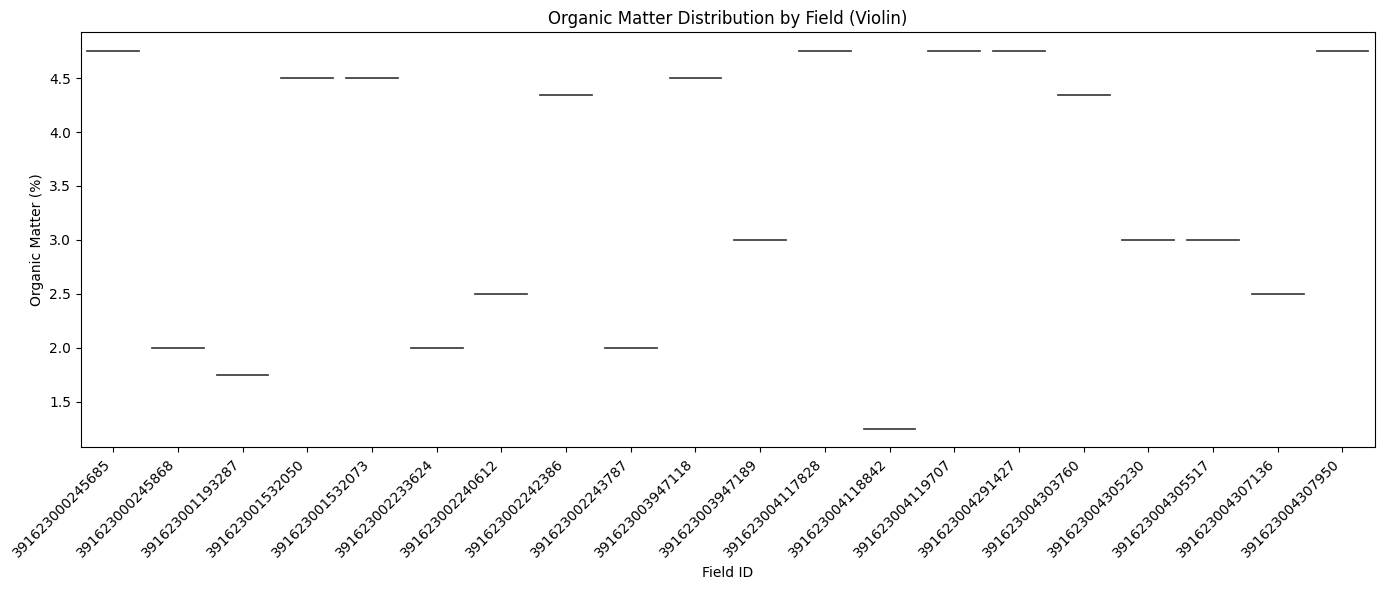

In [4]:
# CREATE VISUALS: SOIL ORGANIC MATTER DISTRIBUTION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load data
df = pd.read_csv('../data/assignment-02/field_summary.csv')
# --- 1. Histogram with KDE ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['organic_matter'], kde=True, bins=20, color='steelblue', ax=ax)
ax.set_title('Distribution of Organic Matter Across Fields')
ax.set_xlabel('Organic Matter (%)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
# --- 2. Box plot by field ---
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='field_id', y='organic_matter', data=df, ax=ax)
ax.set_title('Organic Matter Distribution by Field')
ax.set_xlabel('Field ID')
ax.set_ylabel('Organic Matter (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# --- 3. Violin plot by field ---
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(x='field_id', y='organic_matter', data=df, inner='box', palette='muted')
ax.set_title('Organic Matter Distribution by Field (Violin)')
ax.set_xlabel('Field ID')
ax.set_ylabel('Organic Matter (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

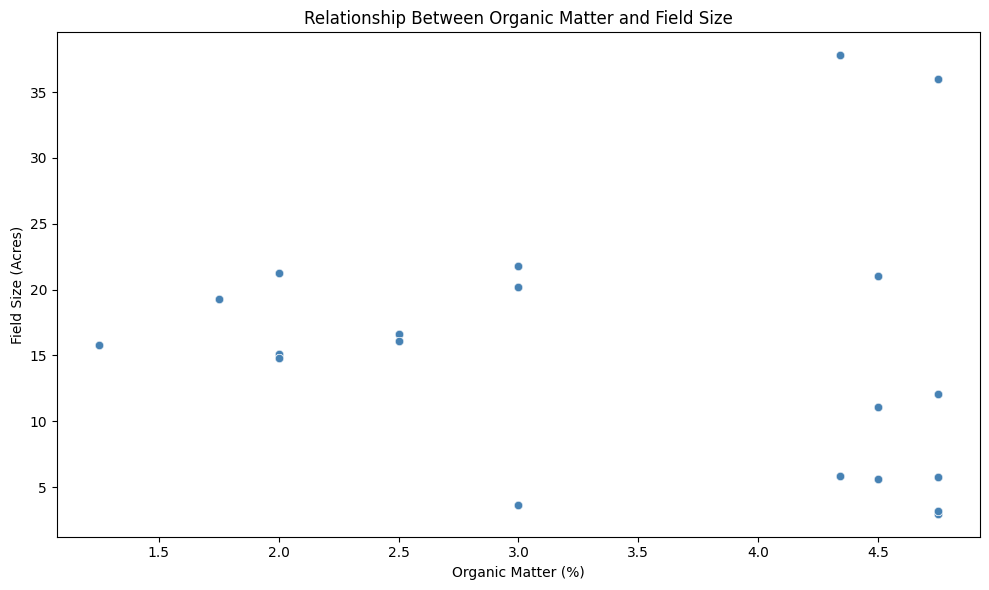

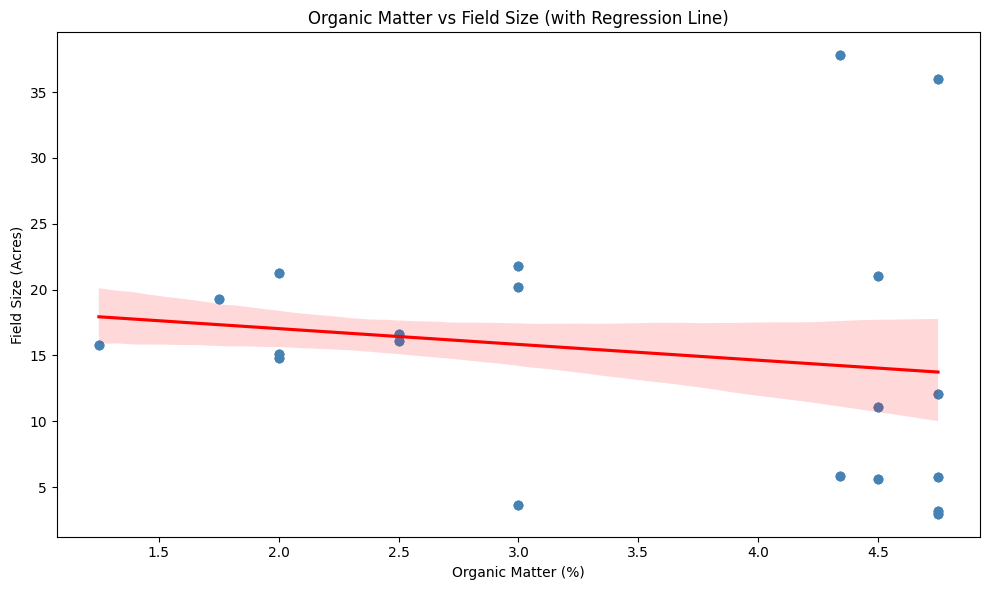

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/assignment-02/field_summary.csv')

# Scatter plot: organic_matter vs field_size_acres
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='organic_matter', y='field_size_acres', data=df, ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Relationship Between Organic Matter and Field Size')
ax.set_xlabel('Organic Matter (%)')
ax.set_ylabel('Field Size (Acres)')
plt.tight_layout()
plt.show()

# add a regression line to see the trend more clearly:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='organic_matter', y='field_size_acres', data=df, ax=ax,
            scatter_kws={'alpha': 0.7, 'color': 'steelblue'},
            line_kws={'color': 'red'})
ax.set_title('Organic Matter vs Field Size (with Regression Line)')
ax.set_xlabel('Organic Matter (%)')
ax.set_ylabel('Field Size (Acres)')
plt.tight_layout()
plt.show()

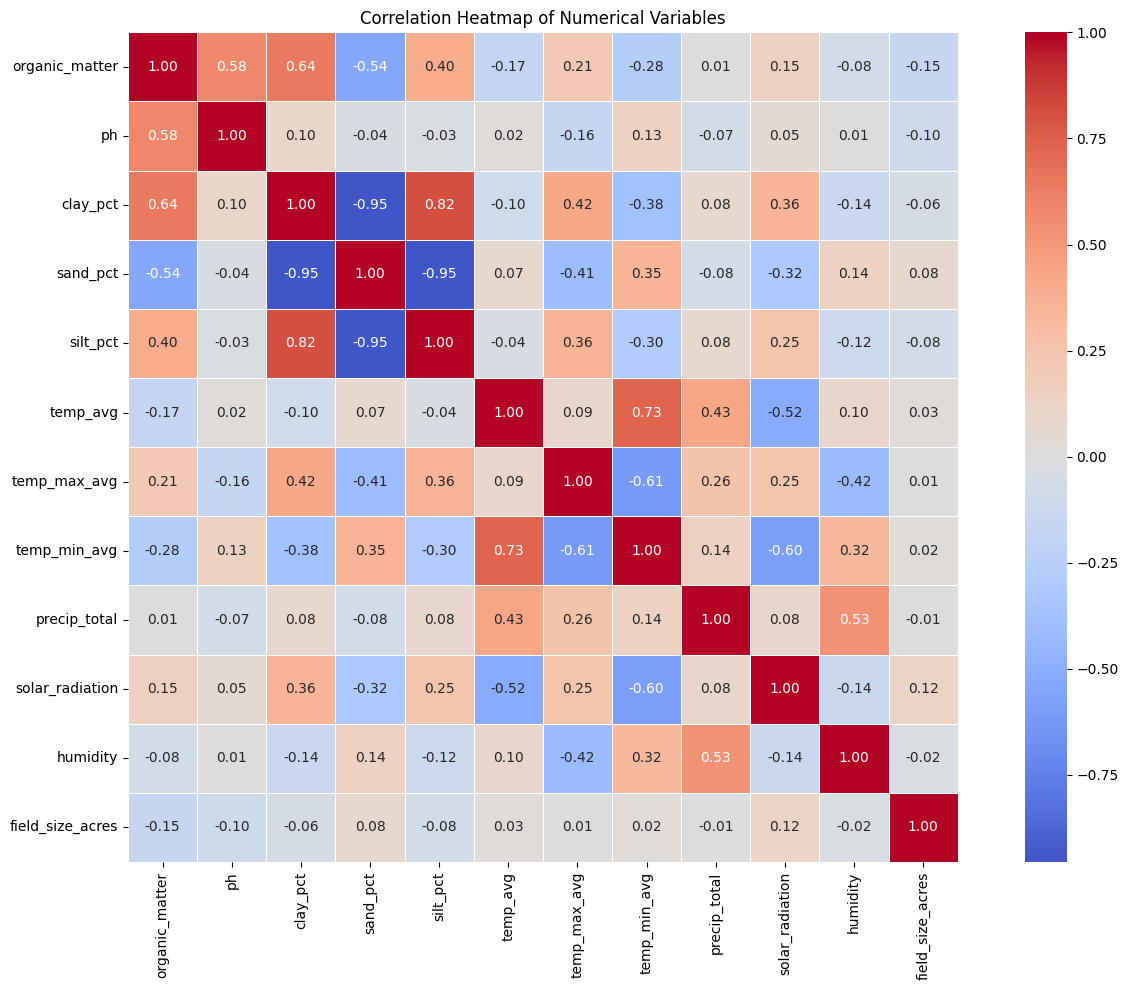

In [10]:
# HEATMAP

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/assignment-02/field_summary.csv')
# Select numerical variables
num_cols = ['organic_matter', 'ph', 'clay_pct', 'sand_pct', 'silt_pct',
            'temp_avg', 'temp_max_avg', 'temp_min_avg',
            'precip_total', 'solar_radiation', 'humidity', 'field_size_acres']
corr = df[num_cols].corr()
# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

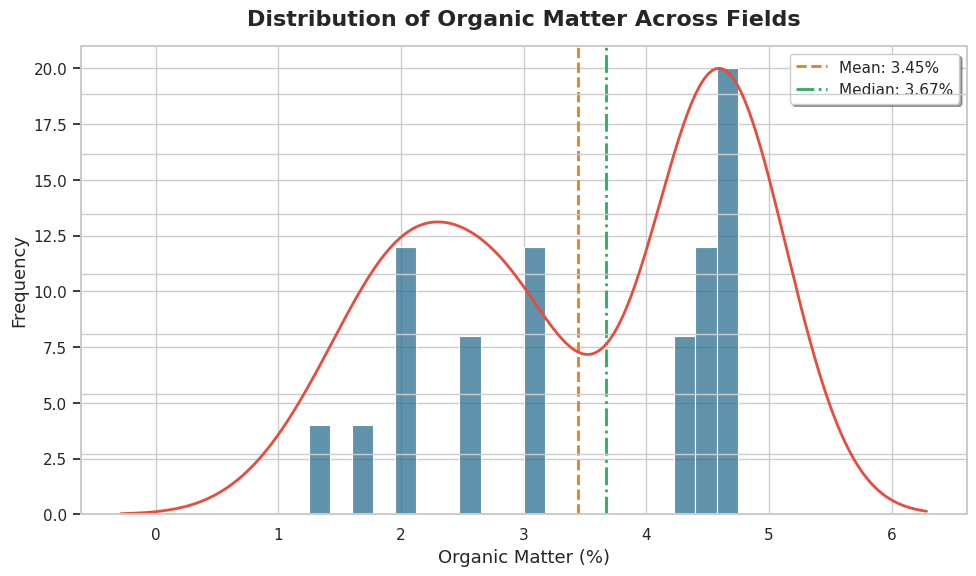

Saved: output/dashboard_assets/organic_matter_distribution.png


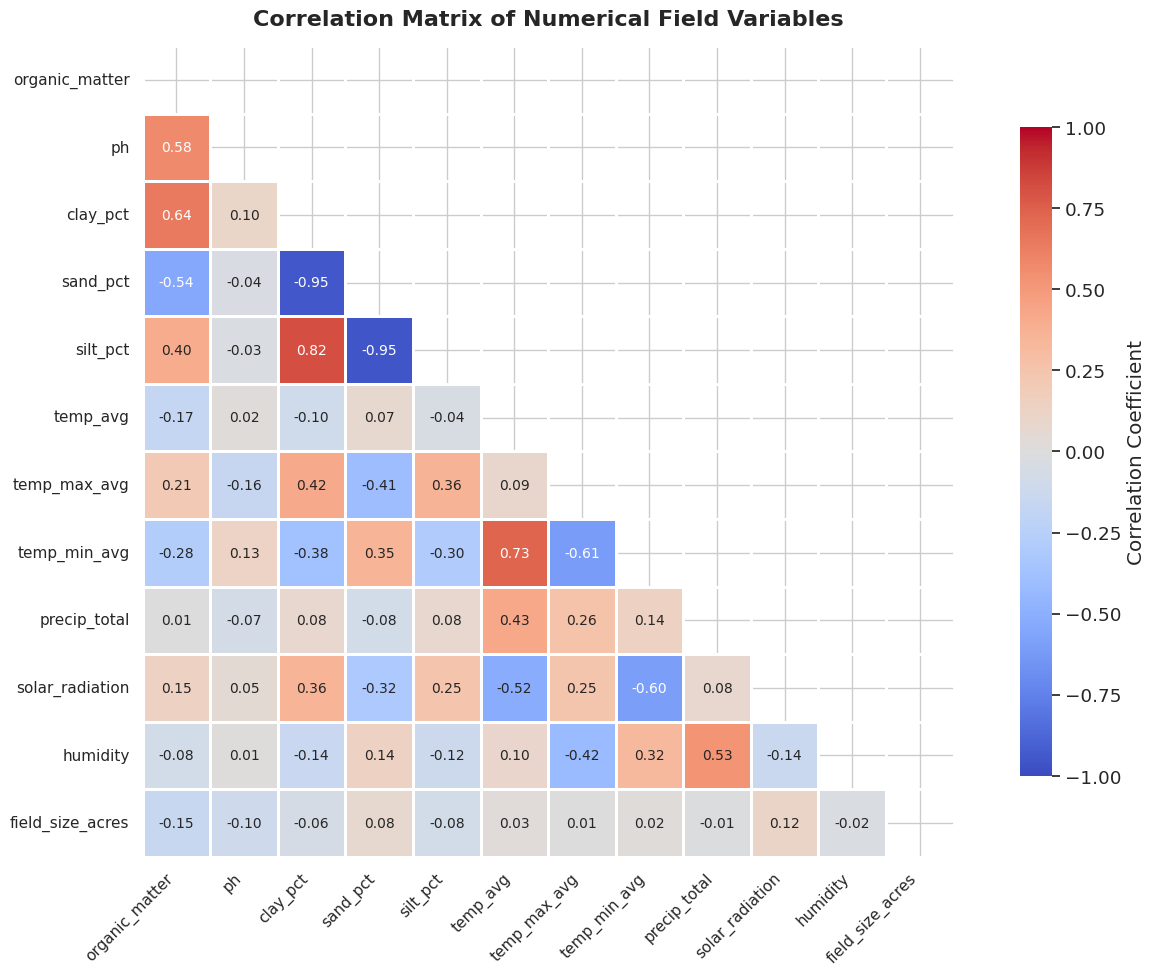

Saved: output/dashboard_assets/correlation_heatmap.png


In [15]:
# FINAL/REFINED IMAGES FOR THE DASHBOARD

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
# Load data
df = pd.read_csv('../data/assignment-02/field_summary.csv')
# Create output directory
os.makedirs('output/dashboard_assets', exist_ok=True)
# --- Global Style Settings ---
sns.set_theme(style='whitegrid', font_scale=1.2)
PALETTE_PRIMARY = '#2C6E91'
PALETTE_ACCENT = '#E74C3C'
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13
TICK_FONTSIZE = 11
DPI = 300
# ============================================================
# PLOT 1: Distribution of Organic Matter (Histogram + KDE)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
# Histogram only (no kde)
sns.histplot(df['organic_matter'], kde=False, bins=20,
             color=PALETTE_PRIMARY, edgecolor='white', linewidth=0.8, ax=ax)
# KDE overlay drawn separately with full style control
sns.kdeplot(df['organic_matter'], color=PALETTE_ACCENT, linewidth=2, ax=ax.twinx())
ax.figure.axes[-1].set_ylabel('')  # hide secondary y-axis label
ax.figure.axes[-1].tick_params(right=False, labelright=False)
# Add mean and median lines
mean_val = df['organic_matter'].mean()
median_val = df['organic_matter'].median()
ax.axvline(mean_val, color='#E67E22', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}%')
ax.axvline(median_val, color='#27AE60', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}%')
ax.set_title('Distribution of Organic Matter Across Fields', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
ax.set_xlabel('Organic Matter (%)', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Frequency', fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)
ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
fig.savefig('output/dashboard_assets/organic_matter_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved: output/dashboard_assets/organic_matter_distribution.png")
# ============================================================
# PLOT 2: Correlation Heatmap (Lower Triangle, Masked)
# ============================================================
num_cols = ['organic_matter', 'ph', 'clay_pct', 'sand_pct', 'silt_pct',
             'temp_avg', 'temp_max_avg', 'temp_min_avg',
            'precip_total', 'solar_radiation', 'humidity', 'field_size_acres']
corr = df[num_cols].corr()
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'fontweight': 'medium'},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)
ax.set_title('Correlation Matrix of Numerical Field Variables', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=45)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.tight_layout()
fig.savefig('output/dashboard_assets/correlation_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved: output/dashboard_assets/correlation_heatmap.png")